In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab datasets/Soil-Climate-data.csv')

In [3]:
print(df.shape)

(10000, 11)


In [4]:
print(df.columns)

Index(['Crop_Type', 'Soil_Type', 'Farm_Size_Acres', 'Irrigation_Available',
       'Soil_pH', 'Soil_Nitrogen', 'Soil_Organic_Matter', 'Temperature',
       'Rainfall', 'Humidity', 'Compatible'],
      dtype='object')


In [5]:
df.head()

,Crop_Type,Soil_Type,Farm_Size_Acres,Irrigation_Available,Soil_pH,Soil_Nitrogen,Soil_Organic_Matter,Temperature,Rainfall,Humidity,Compatible
0,summer paddy,Red and Yellow soils,79.838232,0,5.178290,198.870486,1.458550,20.172143,1861.635725,57.924332,0
1,Kulthi,Alluvial soils,33.932796,1,4.862699,27.781680,2.530317,33.646919,1400.435779,53.261910,0
2,Arhar,Laterite soils,59.673206,1,7.691357,62.500094,4.656399,22.535805,574.308028,65.547263,0
3,Gram,Alluvial soils,50.000261,0,6.482151,134.655093,2.268048,25.672081,1900.397115,34.972994,0
4,summer paddy,Red and Yellow soils,94.628058,0,6.054078,69.894889,1.448071,14.366488,1568.615247,25.953544,0


In [6]:
print(df.isnull().sum())

Crop_Type               0
Soil_Type               0
Farm_Size_Acres         0
Irrigation_Available    0
Soil_pH                 0
Soil_Nitrogen           0
Soil_Organic_Matter     0
Temperature             0
Rainfall                0
Humidity                0
Compatible              0
dtype: int64


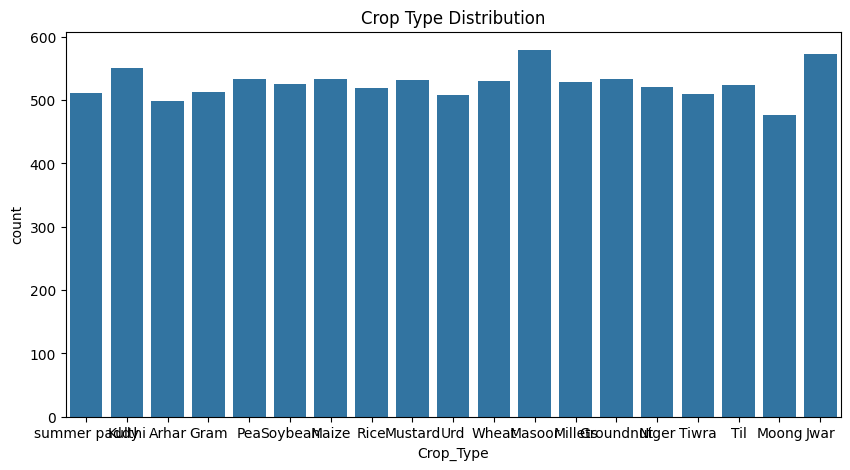

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.countplot(
    x='Crop_Type',
    data=df
)

plt.title("Crop Type Distribution")

plt.xticks(rotation=0)

plt.show()

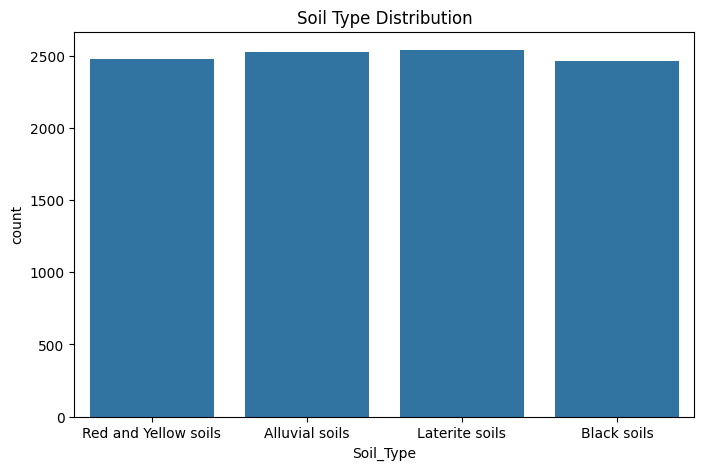

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Soil_Type',
    data=df
)

plt.title("Soil Type Distribution")

plt.xticks(rotation=0)

plt.show()

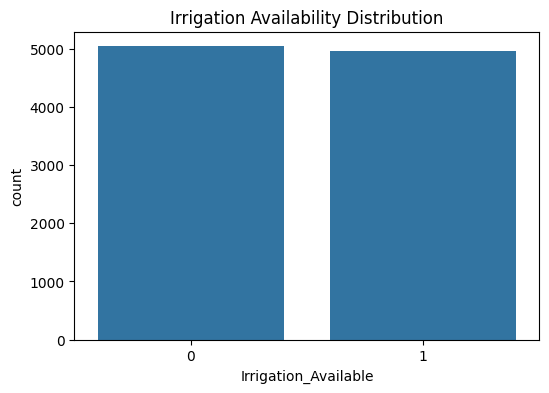

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Irrigation_Available',
    data=df
)

plt.title("Irrigation Availability Distribution")

plt.show()

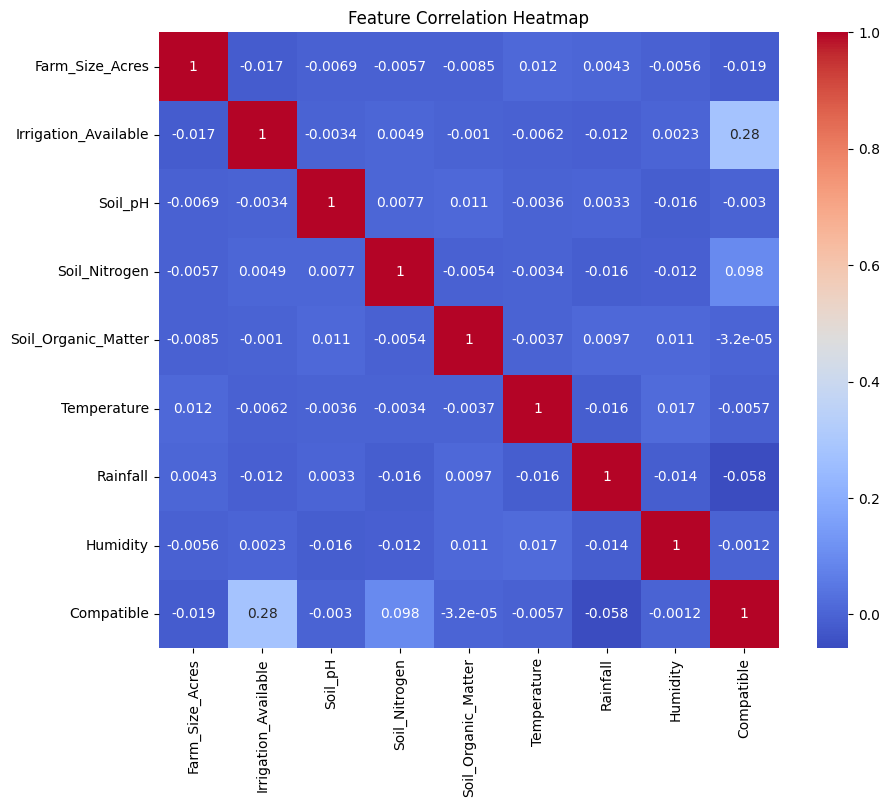

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

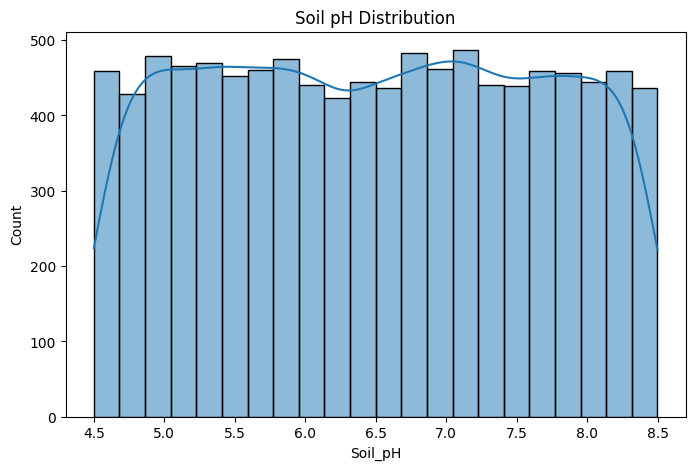

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Soil_pH'],
    kde=True
)

plt.title("Soil pH Distribution")

plt.show()

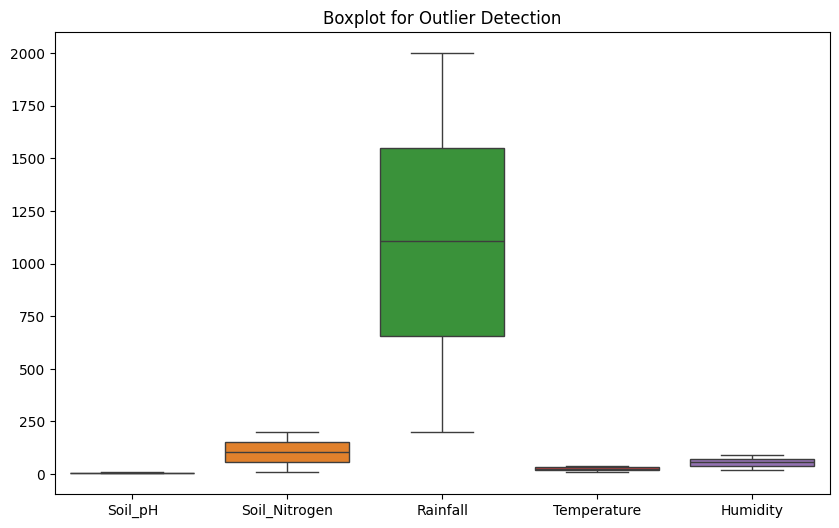

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df[['Soil_pH',
                     'Soil_Nitrogen',
                     'Rainfall',
                     'Temperature',
                     'Humidity']])

plt.title("Boxplot for Outlier Detection")

plt.show()

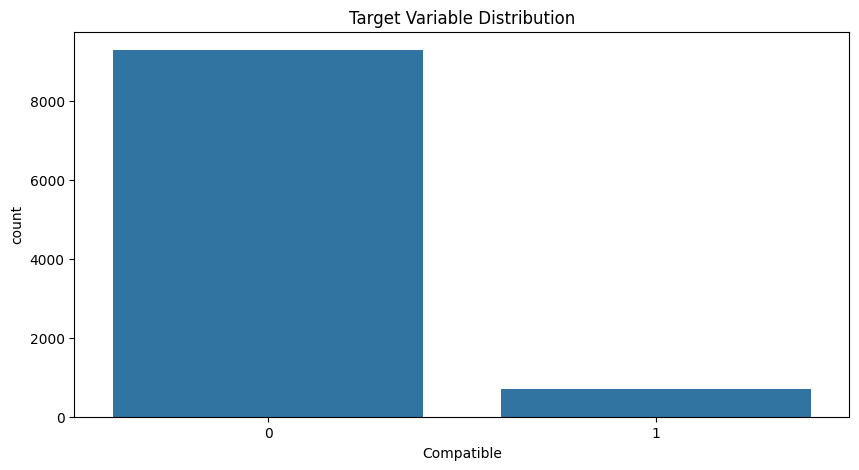

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(x=df['Compatible'])

plt.title("Target Variable Distribution")

plt.show()

In [14]:
from sklearn.preprocessing import LabelEncoder

le_crop = LabelEncoder()
le_soil = LabelEncoder()

# Encode columns
df['Crop_Type'] = le_crop.fit_transform(df['Crop_Type'])

df['Soil_Type'] = le_soil.fit_transform(df['Soil_Type'])


In [15]:
# Define features and target
X = df.drop("Compatible", axis=1)
y = df["Compatible"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Classification Models**

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.998


In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.998


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=500)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9225


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.999


In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_acc = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.9085


In [22]:
from sklearn.svm import SVC

svm = SVC(random_state=42)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.9225


In [23]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_acc = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.8335


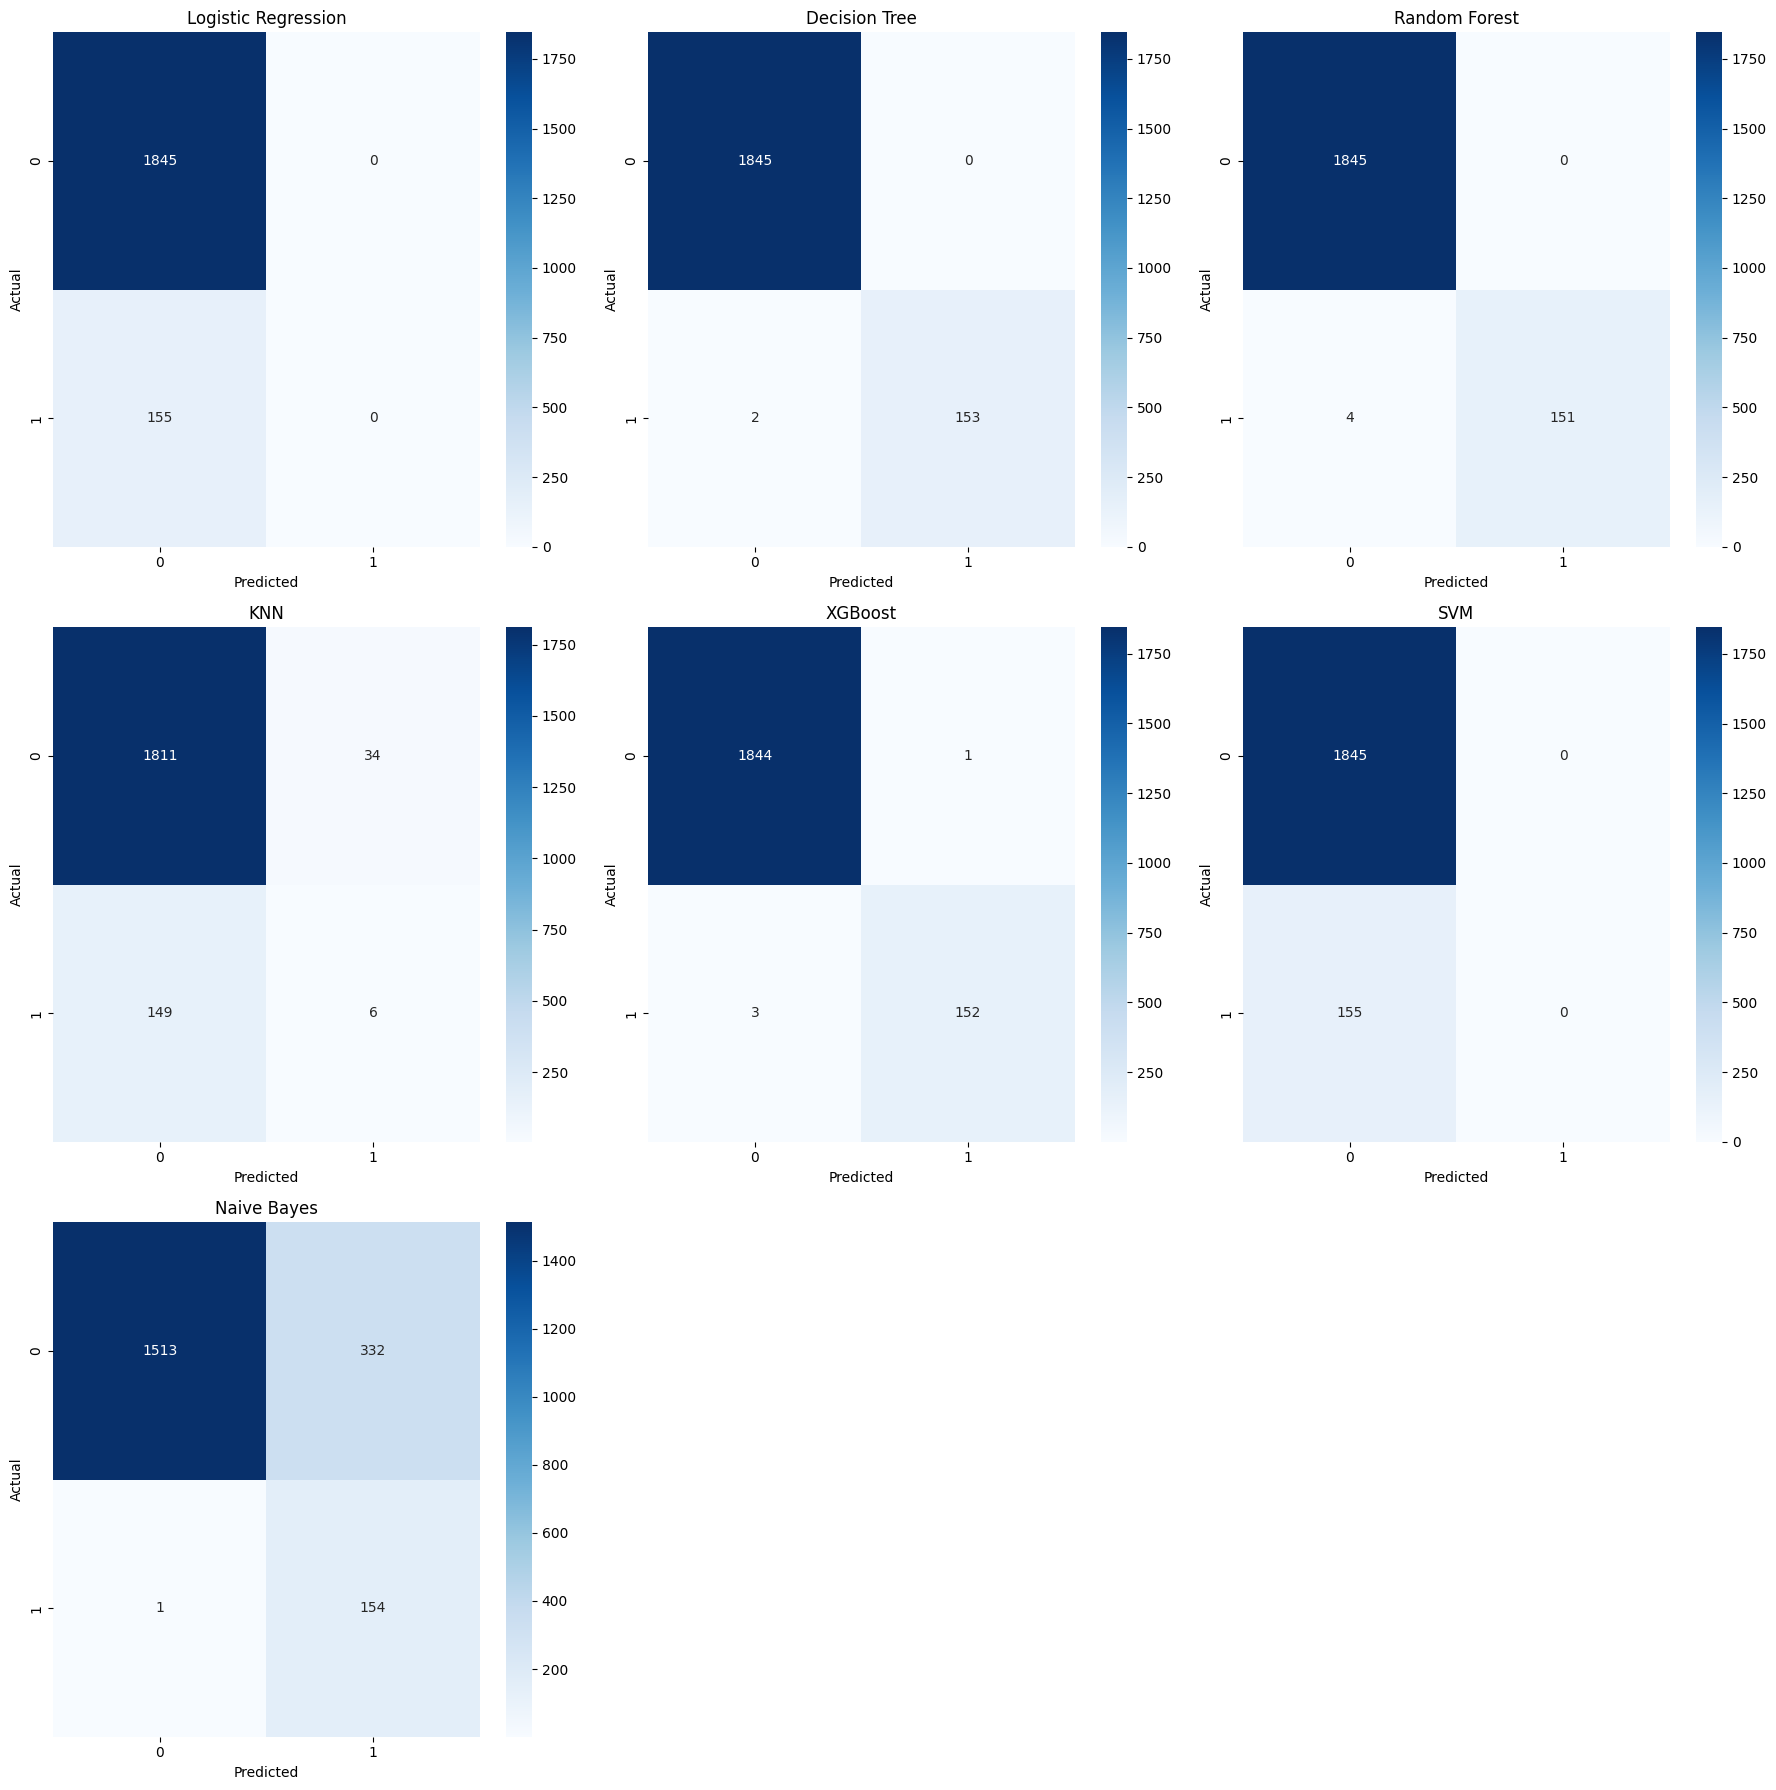

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Store predictions in dictionary
predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "XGBoost": y_pred_xgb,
    "SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb
}

# Plot confusion matrices
plt.figure(figsize=(18, 18)) # Adjusted figsize for more plots

for i, (name, y_pred) in enumerate(predictions.items()):

    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(3, 3, i + 1) # Adjusted subplot to 3 rows, 3 columns

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import classification_report

models_preds = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "XGBoost": y_pred_xgb,
    "SVM": y_pred_svm,
    "Naive Bayes": y_pred_nb
}

for name, pred in models_preds.items():
    print("\n", name)
    print(classification_report(y_test, pred))


 Logistic Regression
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1845
           1       0.00      0.00      0.00       155

    accuracy                           0.92      2000
   macro avg       0.46      0.50      0.48      2000
weighted avg       0.85      0.92      0.89      2000


 Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1845
           1       1.00      0.99      0.99       155

    accuracy                           1.00      2000
   macro avg       1.00      0.99      1.00      2000
weighted avg       1.00      1.00      1.00      2000


 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1845
           1       1.00      0.97      0.99       155

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

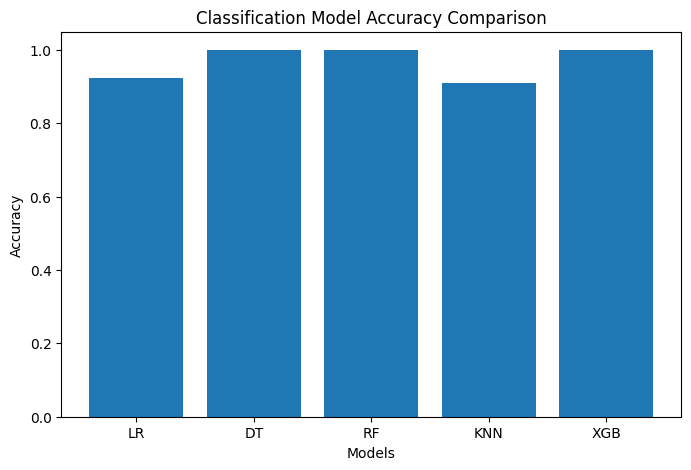

In [26]:
import matplotlib.pyplot as plt

models = ['LR','DT','RF','KNN','XGB']
accuracy = [lr_acc, dt_acc, rf_acc, knn_acc, xgb_acc]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.title("Classification Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.show()

**Clustering**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 33.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395100 sha256=1ab5080eca5cbd11ab96091ff3688ebf6c21621126f6ada11ae7c80986f4f208
  Stored in directory: /root/.cache/pip/wheels/68/29/b4/131bd7deec3663cc311ab9aa64d6517c3e3ec24bcadfc32f74
Successfully built pyclustering
K-Medoids Cluster Distribution (pyclustering):
KMedoids_Cluster_pyclustering
0    3526
1    3251
2    3223
Name: count, dtype: int64


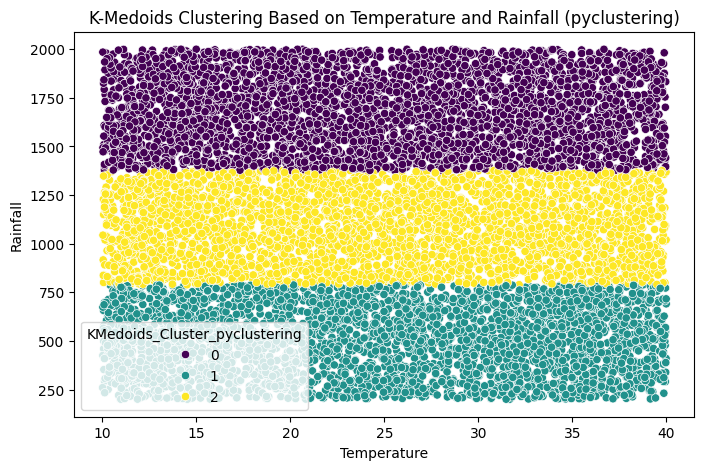

In [27]:
# Due to persistent incompatibility issues with scikit-learn-extra and NumPy 2.x (which is standard for Python 3.12),
# we will use the pyclustering library for K-Medoids instead.
# First, uninstall the conflicting scikit-learn-extra package.
!pip uninstall -y scikit-learn-extra

# Install pyclustering for K-Medoids implementation.
!pip install pyclustering

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import distance_metric, type_metric

# Select numeric columns for clustering
X_cluster = df.select_dtypes(include=['float64','int64']).values # Convert to numpy array for pyclustering

# Initial medoids (randomly choose 3 data points as initial medoids)
np.random.seed(42)
initial_medoids = np.random.choice(range(len(X_cluster)), 3, replace=False)

# Create K-Medoids algorithm instance
# We'll use Euclidean distance as an example
metric = distance_metric(type_metric.EUCLIDEAN)
kmedoids_instance = kmedoids(X_cluster.tolist(), initial_medoids.tolist(), metric=metric)

# Run clustering algorithm
kmedoids_instance.process()

# Get clusters and medoids
clusters_pyclustering = kmedoids_instance.get_clusters()
medoids = kmedoids_instance.get_medoids()

# Assign cluster labels to original DataFrame
df['KMedoids_Cluster_pyclustering'] = -1 # Initialize with a placeholder
for cluster_id, cluster_indices in enumerate(clusters_pyclustering):
    for index in cluster_indices:
        df.loc[index, 'KMedoids_Cluster_pyclustering'] = cluster_id

print("K-Medoids Cluster Distribution (pyclustering):")
print(df['KMedoids_Cluster_pyclustering'].value_counts())

# Visualize K-Medoids Clustering
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Temperature'],
    y=df['Rainfall'],
    hue=df['KMedoids_Cluster_pyclustering'],
    palette='viridis'
)

plt.title("K-Medoids Clustering Based on Temperature and Rainfall (pyclustering)")

plt.show()

In [28]:
from sklearn.cluster import KMeans

# Select numeric columns only
X_cluster = df.select_dtypes(include=['float64','int64'])

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_cluster)

df['Cluster'] = clusters

print(df['Cluster'].value_counts())

Cluster
0    3381
2    3359
1    3260
Name: count, dtype: int64


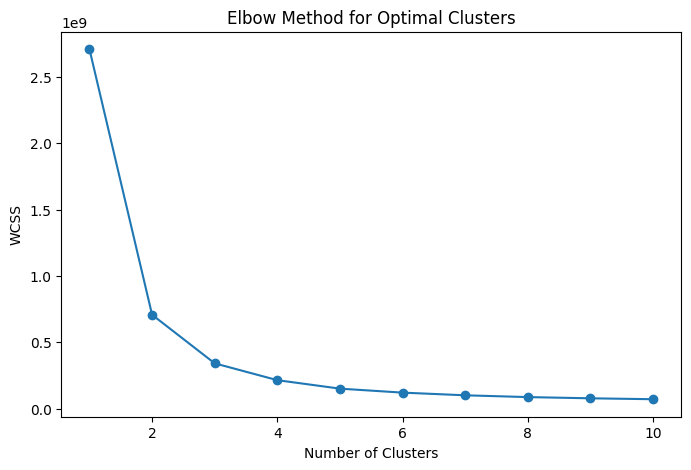

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_cluster)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method for Optimal Clusters")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

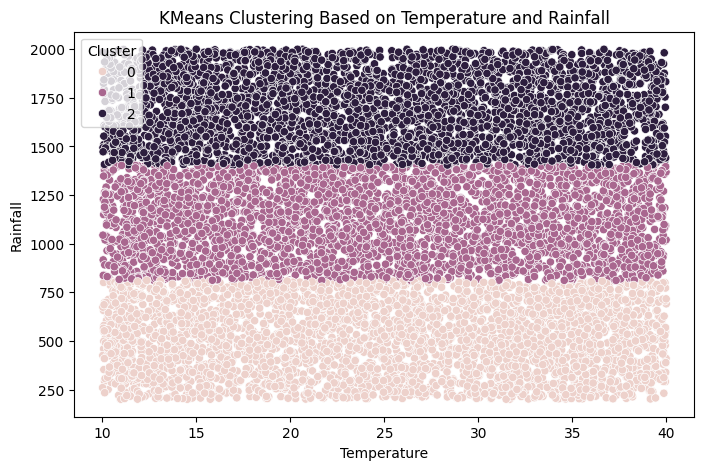

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Temperature'],
    y=df['Rainfall'],
    hue=df['Cluster']
)

plt.title("KMeans Clustering Based on Temperature and Rainfall")

plt.show()

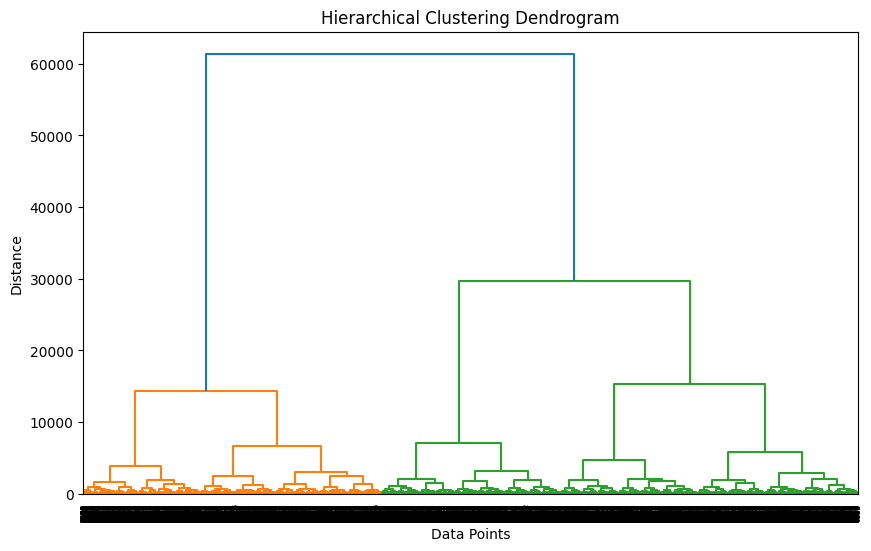

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

X_cluster = df.select_dtypes(include=['float64','int64'])

linked = linkage(X_cluster, method='ward')

plt.figure(figsize=(10,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Distance")

plt.show()


In [32]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3
)

df['HC_Cluster'] = hc.fit_predict(X_cluster)

print(df['HC_Cluster'].value_counts())

HC_Cluster
1    3852
0    3852
2    2296
Name: count, dtype: int64


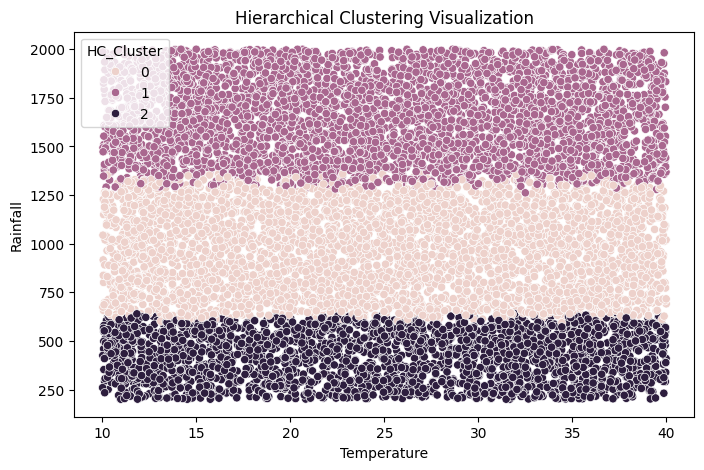

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Temperature'],
    y=df['Rainfall'],
    hue=df['HC_Cluster']
)

plt.title("Hierarchical Clustering Visualization")

plt.show()

Gaussian Mixture Model (EM) Cluster Distribution:
GMM_Cluster
2    3447
1    3302
0    3251
Name: count, dtype: int64


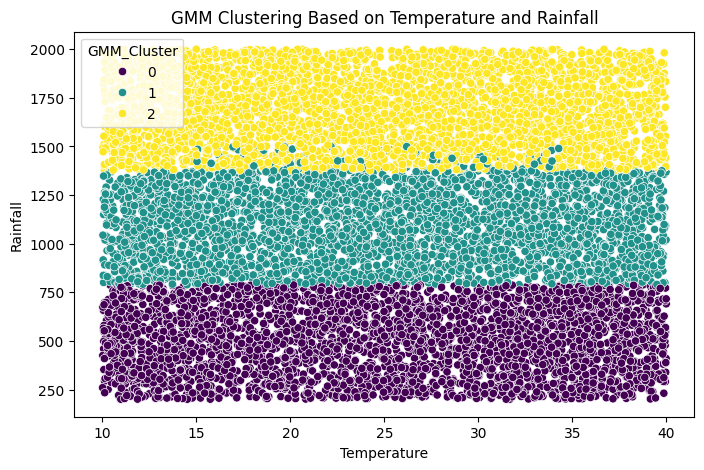

In [35]:
from sklearn.mixture import GaussianMixture

# Select numeric columns for clustering
X_cluster = df.select_dtypes(include=['float64','int64'])

# Initialize and fit Gaussian Mixture Model (EM algorithm)
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_cluster)

# Get cluster labels
df['GMM_Cluster'] = gmm.predict(X_cluster)

print("Gaussian Mixture Model (EM) Cluster Distribution:")
print(df['GMM_Cluster'].value_counts())

# Visualize GMM Clustering
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Temperature'],
    y=df['Rainfall'],
    hue=df['GMM_Cluster'],
    palette='viridis'
)
plt.title("GMM Clustering Based on Temperature and Rainfall")
plt.show()

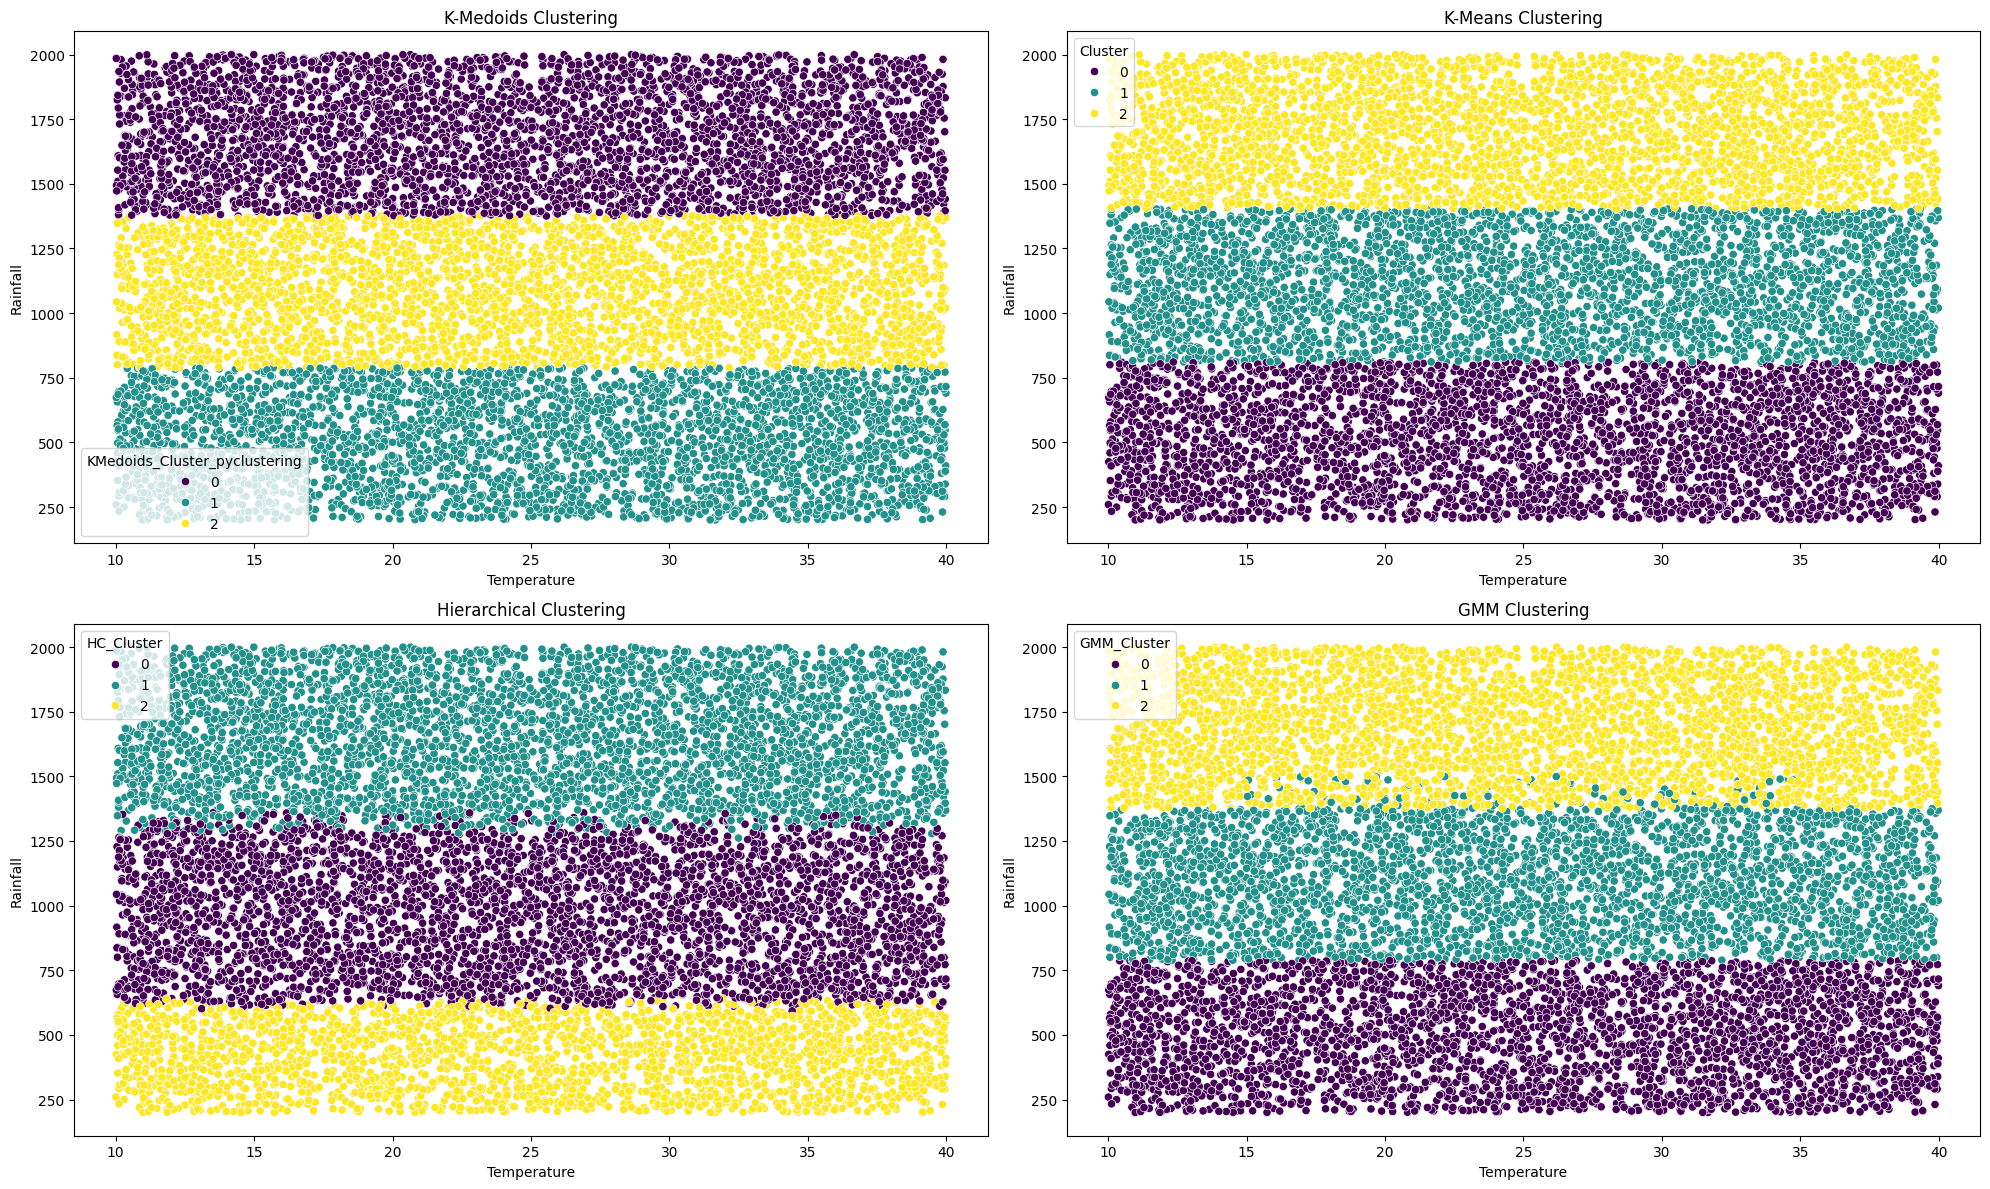

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 12)) # Adjusted figsize for 4 plots

# K-Medoids Clustering Plot
plt.subplot(2, 2, 1) # 2 rows, 2 columns, 1st plot
sns.scatterplot(
    x=df['Temperature'],
    y=df['Rainfall'],
    hue=df['KMedoids_Cluster_pyclustering'],
    palette='viridis'
)
plt.title('K-Medoids Clustering')
plt.xlabel('Temperature')
plt.ylabel('Rainfall')

# K-Means Clustering Plot
plt.subplot(2, 2, 2) # 2 rows, 2 columns, 2nd plot
sns.scatterplot(
    x=df['Temperature'],
    y=df['Rainfall'],
    hue=df['Cluster'],
    palette='viridis'
)
plt.title('K-Means Clustering')
plt.xlabel('Temperature')
plt.ylabel('Rainfall')

# Hierarchical Clustering Plot
plt.subplot(2, 2, 3) # 2 rows, 2 columns, 3rd plot
sns.scatterplot(
    x=df['Temperature'],
    y=df['Rainfall'],
    hue=df['HC_Cluster'],
    palette='viridis'
)
plt.title('Hierarchical Clustering')
plt.xlabel('Temperature')
plt.ylabel('Rainfall')

# GMM Clustering Plot
plt.subplot(2, 2, 4) # 2 rows, 2 columns, 4th plot
sns.scatterplot(
    x=df['Temperature'],
    y=df['Rainfall'],
    hue=df['GMM_Cluster'],
    palette='viridis'
)
plt.title('GMM Clustering')
plt.xlabel('Temperature')
plt.ylabel('Rainfall')

plt.tight_layout()
plt.show()

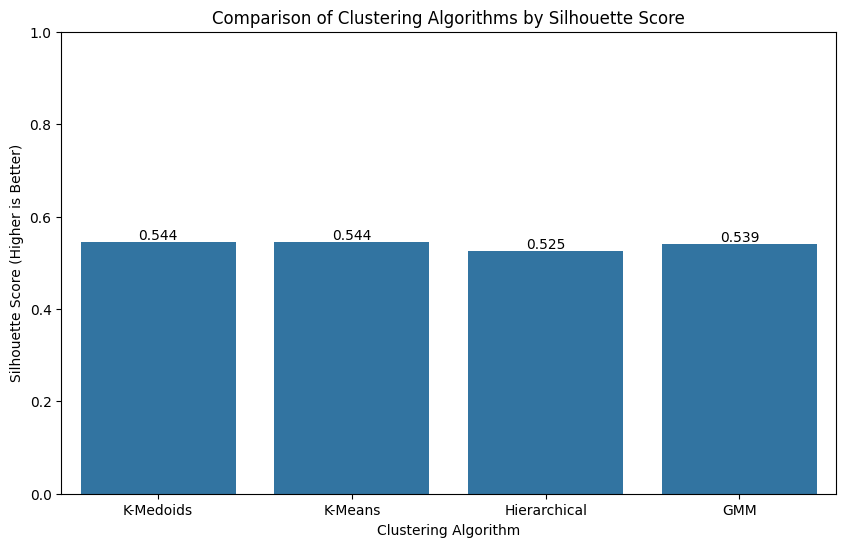

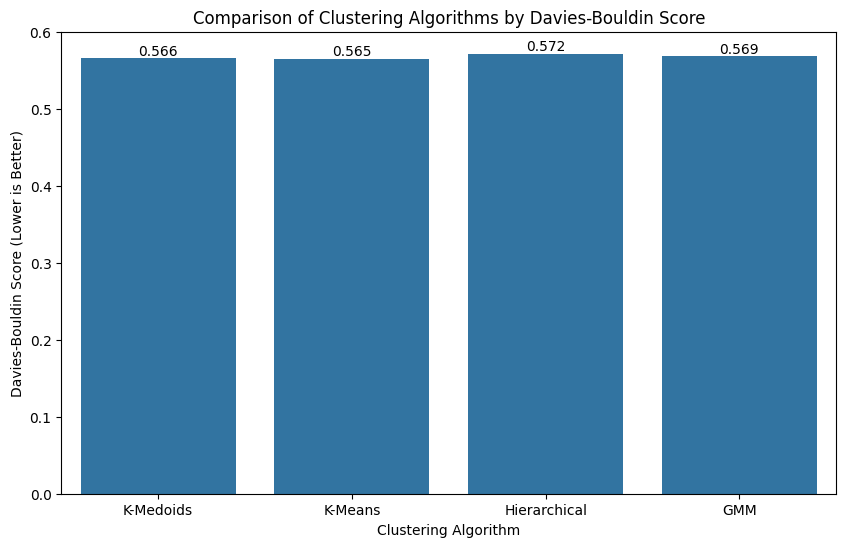

In [45]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare the feature matrix for clustering metrics (numeric columns only)
X_cluster_for_metrics = df.select_dtypes(include=['float64','int64']).values

# Get cluster labels for each algorithm
kmedoids_labels = df['KMedoids_Cluster_pyclustering']
kmeans_labels = df['Cluster']
hc_labels = df['HC_Cluster']
gmm_labels = df['GMM_Cluster']

silhouette_scores = {}
davies_bouldin_scores = {}

# Calculate metrics for each clustering algorithm
clustering_algorithms = {
    'K-Medoids': kmedoids_labels,
    'K-Means': kmeans_labels,
    'Hierarchical': hc_labels,
    'GMM': gmm_labels
}

for name, labels in clustering_algorithms.items():
    # Ensure there are enough distinct labels for metrics calculation
    if len(set(labels)) > 1 and len(set(labels)) < len(X_cluster_for_metrics):
        try:
            silhouette_scores[name] = silhouette_score(X_cluster_for_metrics, labels)
            davies_bouldin_scores[name] = davies_bouldin_score(X_cluster_for_metrics, labels)
        except Exception as e:
            print(f"Error calculating metrics for {name}: {e}")
            silhouette_scores[name] = None
            davies_bouldin_scores[name] = None
    else:
        print(f"Skipping {name}: Not enough distinct clusters or too many clusters for metric calculation.")
        silhouette_scores[name] = None
        davies_bouldin_scores[name] = None

# Create DataFrames for plotting
silhouette_df = pd.DataFrame(list(silhouette_scores.items()), columns=['Clustering Algorithm', 'Silhouette Score'])
davies_bouldin_df = pd.DataFrame(list(davies_bouldin_scores.items()), columns=['Clustering Algorithm', 'Davies-Bouldin Score'])

# Plotting Silhouette Score
plt.figure(figsize=(10, 6))
ax1 = sns.barplot(x='Clustering Algorithm', y='Silhouette Score', data=silhouette_df.dropna())
plt.title('Comparison of Clustering Algorithms by Silhouette Score')
plt.ylabel('Silhouette Score (Higher is Better)')
plt.ylim(0, 1) # Silhouette score ranges from -1 to 1, adjusted for positive values

# Add numbers on top of the bars for Silhouette Score
for index, row in silhouette_df.dropna().iterrows():
    ax1.text(index, row['Silhouette Score'], round(row['Silhouette Score'], 3), color='black', ha="center", va='bottom')
plt.show()

# Plotting Davies-Bouldin Score
plt.figure(figsize=(10, 6))
ax2 = sns.barplot(x='Clustering Algorithm', y='Davies-Bouldin Score', data=davies_bouldin_df.dropna())
plt.title('Comparison of Clustering Algorithms by Davies-Bouldin Score')
plt.ylabel('Davies-Bouldin Score (Lower is Better)')

# Add numbers on top of the bars for Davies-Bouldin Score
for index, row in davies_bouldin_df.dropna().iterrows():
    ax2.text(index, row['Davies-Bouldin Score'], round(row['Davies-Bouldin Score'], 3), color='black', ha="center", va='bottom')
plt.show()

**ANN (Artificial Neural Network)**

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ANN Model
ann = Sequential()

ann.add(Dense(
    64,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

ann.add(Dense(32, activation='relu'))

ann.add(Dense(len(set(y)), activation='softmax'))

ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train ANN
history_ann = ann.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8834 - loss: 4.0016 - val_accuracy: 0.6850 - val_loss: 0.7935
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8898 - loss: 0.6303 - val_accuracy: 0.9225 - val_loss: 0.8490
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8967 - loss: 0.7408 - val_accuracy: 0.9225 - val_loss: 0.5290
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8885 - loss: 0.7314 - val_accuracy: 0.9180 - val_loss: 0.2883
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8972 - loss: 0.6576 - val_accuracy: 0.9225 - val_loss: 0.4194
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8992 - loss: 0.6084 - val_accuracy: 0.9225 - val_loss: 1.4041
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8996 - loss: 0.4897 - val_accuracy: 0.9150 - val_loss: 0.2197
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8974 - loss: 0.6905 - val_accuracy: 0.5640 - val_

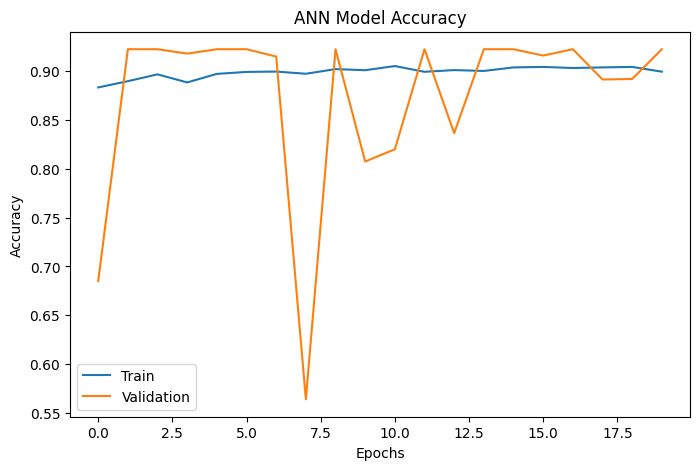

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_ann.history['accuracy'])
plt.plot(history_ann.history['val_accuracy'])

plt.title("ANN Model Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# DNN Model
dnn = Sequential()

dnn.add(Dense(
    128,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

dnn.add(Dense(64, activation='relu'))

dnn.add(Dense(32, activation='relu'))

dnn.add(Dropout(0.3))

dnn.add(Dense(len(set(y)), activation='softmax'))

dnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train DNN
history_dnn = dnn.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9133 - loss: 1.3807 - val_accuracy: 0.9225 - val_loss: 0.2624
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9308 - loss: 0.2712 - val_accuracy: 0.9225 - val_loss: 0.2554
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9309 - loss: 0.2601 - val_accuracy: 0.9225 - val_loss: 0.2531
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9309 - loss: 0.2516 - val_accuracy: 0.9225 - val_loss: 0.2445
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9309 - loss: 0.2471 - val_accuracy: 0.9225 - val_loss: 0.2423
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9305 - loss: 0.2450 - val_accuracy: 0.9225 - val_loss: 0.2484
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9309 - loss: 0.2411 - val_accuracy: 0.9225 - val_loss: 0.2395
Epoch 8/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9309 - loss: 0.2369 - val_accuracy: 0.9225 - val_

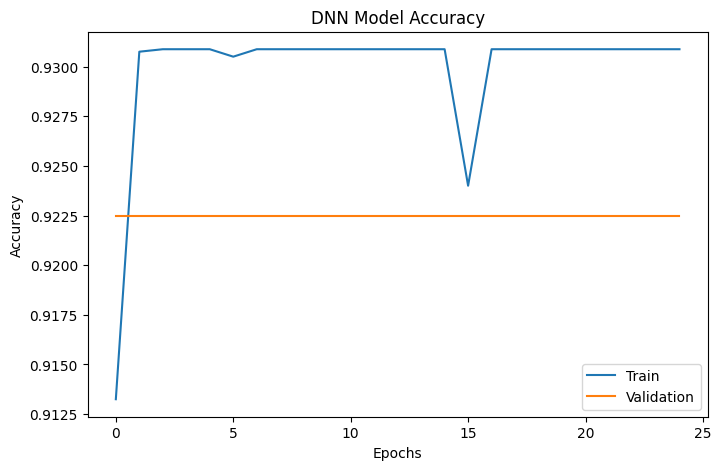

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history_dnn.history['accuracy'])
plt.plot(history_dnn.history['val_accuracy'])

plt.title("DNN Model Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

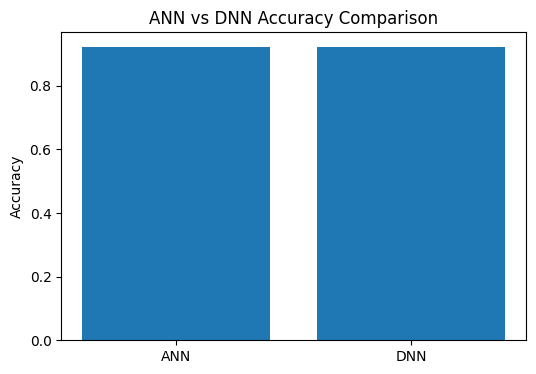

In [41]:
ann_acc = max(history_ann.history['val_accuracy'])
dnn_acc = max(history_dnn.history['val_accuracy'])

models = ['ANN','DNN']
accuracy = [ann_acc, dnn_acc]

plt.figure(figsize=(6,4))

plt.bar(models, accuracy)

plt.title("ANN vs DNN Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [42]:
import joblib

# Save Random Forest model
joblib.dump(
    rf,
    "/content/drive/MyDrive/crop_prediction_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [43]:
joblib.dump(
    le_crop,
    "/content/drive/MyDrive/crop_label_encoder.pkl"
)

joblib.dump(
    le_soil,
    "/content/drive/MyDrive/soil_label_encoder.pkl"
)

print("Encoders saved!")

Encoders saved!
